# Understanding the ELO rating system: A practical example using English Premier League football results using Python

Elo rating (aka. ELO score) is originating from chess, it was invented by a Hungarian mathematician called Arpad Elo to rank chess players. It has many features which make it possible to be used in other fields like sports, and video games to rank people who are competing against each other.

Wikipedia proves a great summary if you would like to read more about the topic: https://en.wikipedia.org/wiki/Elo_rating_system
In our example, we will see how to calculate the ELO ratings for football teams, which will make it possible to rank and calculate winning probabilities for them. By this, we can tell who is the current best team and calculate winning probabilities which can be a basis of a more complex prediction model.

In this example, I will show you how to calculate ELO scores for English Premier League football clubs using Python by writing our own functions.
The packages we need:

YOU CAN FIND THE NOTEBOOK AND DATA ON THE FOLLOWING LINK:  

https://github.com/krinya/pl_elo_score

The packages we need:

In [1]:
# Packages we need (installed via `uv sync`):
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# The ELO + league-table logic lives in elo.py, a single tested source of truth:
from elo import (
    read_results,
    create_league_table,
    update_league_table,
    create_elo_league_table,
    update_elo_league_table,
    expected_result_prob,
    actual_result,
    calculate_elo,
)

Matplotlib is building the font cache; this may take a moment.


## Get data and load it:

For this example we need the results for multiple season of the English premier league. We can find data for this one on the following link: https://www.football-data.co.uk/englandm.php  
I downloaded data for 6 seasons and put all if them to a folder called: 'data/pl' in our root directory. (I also renamed them as this: 'data/pl/pl_2019_2020.csv')

Then I wrote a function to read in all the '.csv' files in one folder, in our case the 'data/pl' folder. ALso it does some minimal clean up.

In [2]:
# `read_results()` is defined in elo.py (imported above).

This data contains other information too but we only need some of the columns (actually we only need the result, for calculating the ELO score).

In [3]:
results_data = read_results(path = 'data/pl', columns_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'filename'], verbose=False)

We can look at the data now, to have a better understanding of what are we dealing with:

In [4]:
results_data

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,filename
0,2020-09-12,Fulham,Arsenal,0,3,A,data/pl/pl_2020_2021.csv
1,2020-09-12,Crystal Palace,Southampton,1,0,H,data/pl/pl_2020_2021.csv
2,2020-09-12,Liverpool,Leeds,4,3,H,data/pl/pl_2020_2021.csv
3,2020-09-12,West Ham,Newcastle,0,2,A,data/pl/pl_2020_2021.csv
4,2020-09-13,West Brom,Leicester,0,3,A,data/pl/pl_2020_2021.csv
...,...,...,...,...,...,...,...
1924,2022-08-20,Leicester,Southampton,1,2,A,data/pl/pl_2022_2023.csv
1925,2022-08-20,Bournemouth,Arsenal,0,3,A,data/pl/pl_2022_2023.csv
1926,2022-08-21,Leeds,Chelsea,3,0,H,data/pl/pl_2022_2023.csv
1927,2022-08-21,West Ham,Brighton,0,2,A,data/pl/pl_2022_2023.csv


The date is pretty self-explanatory: Each line is a match where there is a HomeTeam and an AwayTeam. With the FTHG (Full Time Home Goals) and the FTAG (Full Time Away Goals) and the FTR (Full time results). The FTR can be: 'H' if the home team won, 'A' if the away team won, and 'D' if the match was a draw.

We can see that this data contains almost 2000 matches. My plan is to use 1-2 seasons to calibrate the ELO scores then see whether the aproach works in the 2nd part of the last season.

## Calculate the League table based on the results

What we need to do is to create a league table, which calculates new scores at each time when a match is played. This is something similar if we calculate a ranking at each point. So at this part we will do two things:  

1) create a league_table that we can update at each match
2) create the function which updates this table.

First we will not focus on the ELO score, but implement just the calculation based on the normal football rules, where each win worth +3 points for the wining team, 0 points for the losing team and 1 point for each team if there is a draw.

Later our plan is to add our ELO score calculation here.

### 1) Create League Table:

In [5]:
# `create_league_table()` is defined in elo.py.

Do this for only the 2021-2022 season:

In [6]:
results_data_2022 = results_data[results_data['filename'] == r'data/pl/pl_2021_2022.csv']
lt_2022 = create_league_table(results_data_2022)
lt_2022

,team,ranking,points,w,d,l,goals_for,goals_against,goal_difference,matched_played,last_date
0,Brentford,0,0,0,0,0,0,0,0,0,2021-08-13
1,Man United,0,0,0,0,0,0,0,0,0,2021-08-13
2,Burnley,0,0,0,0,0,0,0,0,0,2021-08-13
3,Chelsea,0,0,0,0,0,0,0,0,0,2021-08-13
4,Everton,0,0,0,0,0,0,0,0,0,2021-08-13
5,Leicester,0,0,0,0,0,0,0,0,0,2021-08-13
6,Watford,0,0,0,0,0,0,0,0,0,2021-08-13
7,Norwich,0,0,0,0,0,0,0,0,0,2021-08-13
8,Newcastle,0,0,0,0,0,0,0,0,0,2021-08-13
9,Tottenham,0,0,0,0,0,0,0,0,0,2021-08-13


Now you can see that we have a table what we can update, but we need the updater function for it.

### 2) Write the function that updates the league table

First I will write this function_without the ELO score. We will be able to do some cool things with it, and in the next part we will add the ELO score.

In [7]:
# `update_league_table()` (plain standings) is defined in elo.py.

In [8]:
#results = results_data
results = results_data_2022
table_data = create_league_table(results)
new_table_data,  league_table_all= update_league_table(table_data, results)

In [9]:
new_table_data

,team,ranking,points,w,d,l,goals_for,goals_against,goal_difference,matched_played,last_date
0,Man City,1,93,29,6,3,99,26,73,38,2022-05-22
1,Liverpool,2,92,28,8,2,94,26,68,38,2022-05-22
2,Chelsea,3,74,21,11,6,76,33,43,38,2022-05-22
3,Tottenham,4,71,22,5,11,69,40,29,38,2022-05-22
4,Arsenal,5,69,22,3,13,61,48,13,38,2022-05-22
5,Man United,6,58,16,10,12,57,57,0,38,2022-05-22
6,West Ham,7,56,16,8,14,60,51,9,38,2022-05-22
7,Leicester,8,52,14,10,14,62,59,3,38,2022-05-22
8,Brighton,9,51,12,15,11,42,44,-2,38,2022-05-22
9,Wolves,10,51,15,6,17,38,43,-5,38,2022-05-22


Is this correct? We can check this if we go to one of the websites with the official final results, see an example below:

![pl_original_league_table](img/league_table_original.png)

It is matching with our calculations, so we can see that our calculations are correct.

### Graphical representation
We can also create some nice plots to display some interesting aspects of our data.

Text(0.5, 1.0, 'Premier League 2021-2022 final results')

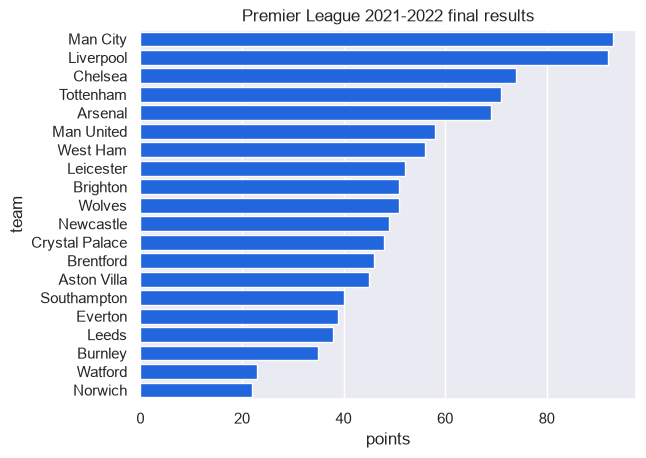

In [10]:
sns.barplot(x = 'points', y = 'team', data = new_table_data, color = '#035efc')
plt.title('Premier League 2021-2022 final results')

Text(0.5, 1.0, 'Premier League avarage points/ match in the 2021-2022 season')

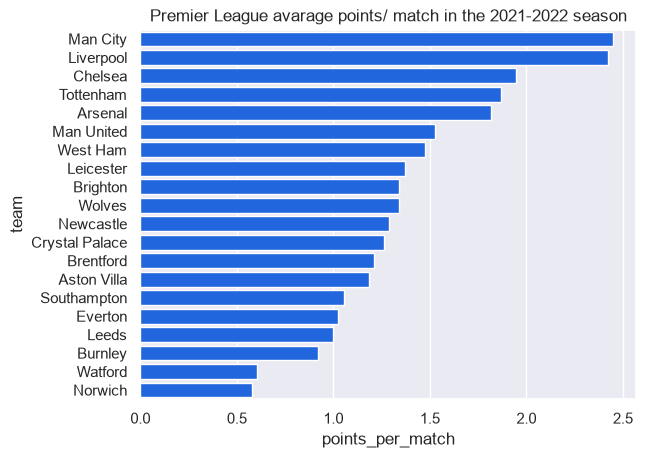

In [11]:
new_table_data['points_per_match'] = new_table_data['points'] / new_table_data['matched_played']
sns.barplot(x = 'points_per_match', y = 'team', data = new_table_data, color = '#035efc', order=new_table_data.sort_values('points_per_match', ascending = False).team)
plt.title('Premier League avarage points/ match in the 2021-2022 season')

We also created another table, called: 'league_table_all' which can be used to see the progression of the metrics. E.g.: If we want to see 3 teams points progression in time we can do that.

Text(0.5, 1.0, 'Premier League points over time')

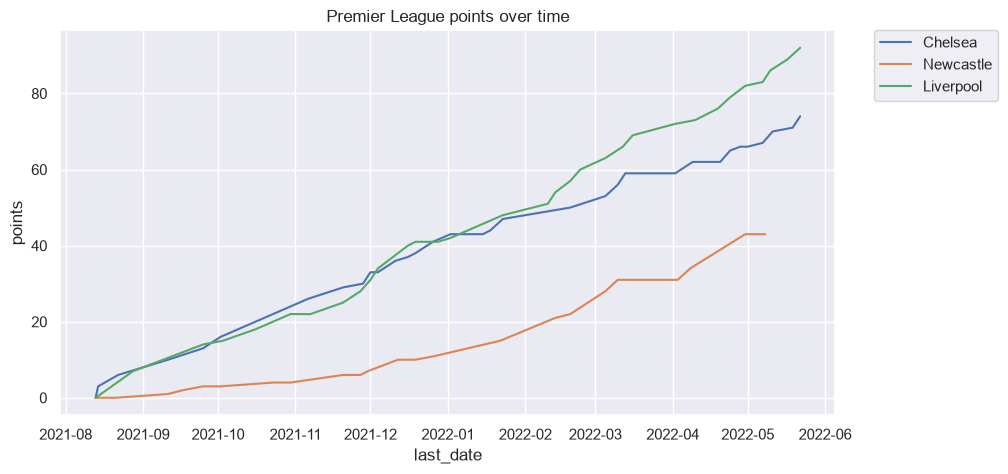

In [12]:
plt.figure(figsize = (10,5))
sns.lineplot(x='last_date', y='points', hue='team', errorbar = None,
    data=league_table_all[league_table_all['team'].isin(['Liverpool', 'Chelsea', 'Newcastle'])])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Premier League points over time')

## Adding the ELO score

In this part I am just copying the functions above and we will extending them with the ELO score calculations.

In [13]:
# `create_elo_league_table()` is defined in elo.py.

For this part we will use all of our result set which contains the 5 previous seasons + the latest results from the 2022-2023 season.

Let's create the league table. Now we not only have 20 teams, but all the teams which were present in the PL for only one season too which adds up to 29.

In [14]:
results_data = read_results(path = 'data/pl', columns_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'filename'], verbose=False)
league_table_elo = create_elo_league_table(results_data, default_elo = 1400)
print(league_table_elo['team'].to_list())

['Fulham', 'Crystal Palace', 'Liverpool', 'West Ham', 'West Brom', 'Tottenham', 'Brighton', 'Sheffield United', 'Everton', 'Leeds', 'Man United', 'Arsenal', 'Southampton', 'Newcastle', 'Chelsea', 'Leicester', 'Aston Villa', 'Wolves', 'Burnley', 'Man City', 'Brentford', 'Watford', 'Norwich', 'Bournemouth', 'Huddersfield', 'Cardiff', 'Stoke', 'Swansea', "Nott'm Forest"]


## Writing the ELO calculation function

To be able to calculate the ELO score, we need two things:

1) __Calculate the expected probability of an outcome, based on two input scores from the two opponents.__ 

    For calculating this we need to use the following formula:
    If player A has a rating of RA and player B a rating of RB, the exact formula for the expected score of player A is:  
    
    EA = 1 / (1 + 10 ˆ ((RB - RA) / weights))
    
    Similarly the expected score for player B is: 
    
    EB = 1 / (1 + 10 ˆ ((RA - RB) / weights))  
    (usually the default weight is set to 400 but we can parametrize this too)  

2) __Based on the actual result update the score with new values for each team.__

    When a player's actual tournament scores exceed their expected scores, the Elo system takes this as evidence that player's rating is too low, and needs to be adjusted upward. Similarly, when a player's actual tournament scores fall short of their expected scores, that player's rating is adjusted downward. Elo's original suggestion, which is still widely used, was a simple linear adjustment proportional to the amount by which a player over-performed or under-performed their expected score. The maximum possible adjustment per game, called the K-factor. This K-factor can be set to differnt values in chess it is set to 16 or 32 based on the level of the players, but we can set it to an arbitrary value that is close to this.
    
    Suppose player A (again with rating RA) was expected to score EA points but actually scored SA points.  
    The formula for updating that player's rating is: R'A = RA * K (SA - EA)

    This update can be performed after each game or each tournament, or after any suitable rating period.

We need three functions to be able to put the whole thing together:  

In [15]:
# `expected_result_prob()` is defined in elo.py.

As you see this function calculates the winning probability for both teams.  
In this function, we can also introduce home-field advantage by just adding a constant.
If you play with the parameters you can see how they are affecting the calculations.

In [16]:
print(expected_result_prob(1500,1400, weight=400))
print(expected_result_prob(1600,1400, weight=400))
print(expected_result_prob(1500,1400, weight=200))
print(expected_result_prob(1500,1400, weight=600))

(np.float64(0.703), np.float64(0.297))
(np.float64(0.808), np.float64(0.192))
(np.float64(0.849), np.float64(0.151))
(np.float64(0.64), np.float64(0.36))


Then we need a function to be able to know which team actually won in real life. And based on that assign a value for the home and away team.

In [17]:
# `actual_result()` is defined in elo.py.

In [18]:
print(actual_result('H'))
print(actual_result('A'))
print(actual_result('D'))

(1.0, 0.0)
(0.0, 1.0)
(0.5, 0.5)


Then we need an updating function that will update the ELO score of both teams:

In [19]:
# `calculate_elo()` is defined in elo.py.

In [20]:
calculate_elo(1500, 1400, 'H')

(np.float64(1511.88),
 np.float64(1388.12),
 [np.float64(11.880000000000003),
  np.float64(-28.119999999999997),
  np.float64(-8.119999999999997),
  np.float64(28.120000000000005),
  np.float64(-11.879999999999999),
  np.float64(8.120000000000001)])

In [21]:
calculate_elo(1500, 1400, 'A')

(np.float64(1471.88),
 np.float64(1428.12),
 [np.float64(11.880000000000003),
  np.float64(-28.119999999999997),
  np.float64(-8.119999999999997),
  np.float64(28.120000000000005),
  np.float64(-11.879999999999999),
  np.float64(8.120000000000001)])

Extend the league table updater function with the ELO calculations:

In [22]:
# `update_elo_league_table()` is defined in elo.py.

Do the actual calculations using data from the 2017 season onwards.

In [23]:
results = read_results(path = 'data/pl', columns_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'filename'], verbose=False)
league_table_elo = create_elo_league_table(results, default_elo=1400)
league_table_elo, league_table_elo_all = update_elo_league_table(league_table_elo, results, k_value = 40, weight = 400, home_field_advantage = 60)

Here we can see:  
- The current ELO score
- the total score which was collected  

These results are based on 5 seasons + the current one too. (you can see the last date when the scores were updated for each team in the 'last_date' column)

In [24]:
league_table_elo

,team,ranking,elo,points,w,d,l,goals_for,goals_against,goal_difference,matched_played,last_date
0,Man City,1,1740.52,465,148,21,24,494,146,348,193,2022-08-21
1,Liverpool,2,1585.40,434,131,41,20,423,164,259,192,2022-08-15
2,Chelsea,3,1503.72,353,103,44,46,331,205,126,193,2022-08-21
3,Tottenham,4,1599.96,347,104,35,54,346,210,136,193,2022-08-20
4,Man United,5,1537.20,345,99,48,45,330,225,105,192,2022-08-13
5,Arsenal,6,1516.32,328,97,37,59,328,239,89,193,2022-08-20
6,Leicester,7,1329.56,280,79,43,71,309,266,43,193,2022-08-20
7,West Ham,8,1344.00,254,70,44,79,271,288,-17,193,2022-08-21
8,Everton,9,1369.88,251,69,44,80,234,278,-44,193,2022-08-20
9,Crystal Palace,10,1423.96,232,60,52,81,222,274,-52,193,2022-08-20


Text(0.5, 1.0, 'Elo score of teams')

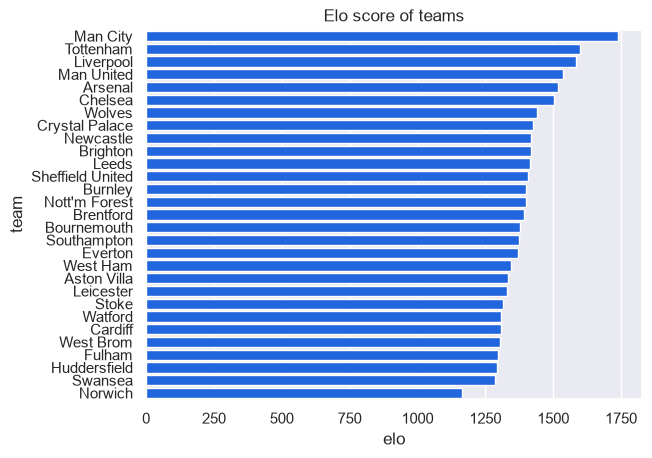

In [25]:
sns.barplot(x = 'elo', y = 'team', data = league_table_elo, color = '#035efc', order=league_table_elo.sort_values('elo', ascending = False).team)
plt.title('Elo score of teams')

We can also represent the progression of the scores in time, from a given date. Remember, that at the beginning each team starts from the same score so it takes some time to converge to the real score, at the beginning of our series the score are not well calibrated and can be off. That's why we do not want to look at the beginning of our series.

Text(0.5, 1.0, 'ELO score progression for some PL clubs')

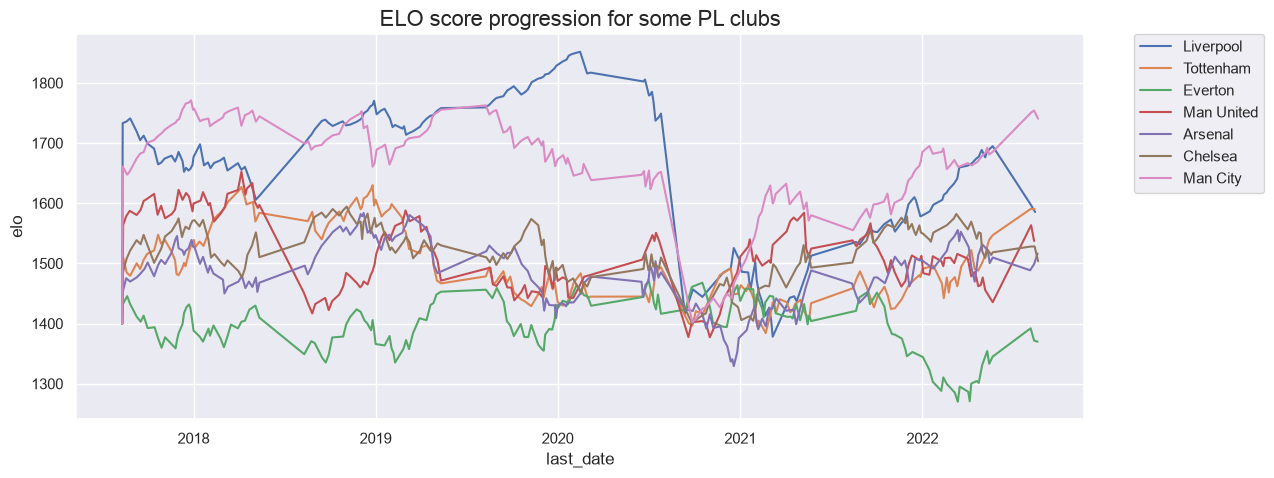

In [26]:
plt.figure(figsize = (13,5))
sns.lineplot(x='last_date', y='elo', hue='team', errorbar=None,
    data=league_table_elo_all[league_table_elo_all['team'].isin(['Arsenal', 'Chelsea', 'Liverpool', 'Man City', 'Man United', 'Tottenham', 'Everton'])])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('ELO score progression for some PL clubs', size = 16)

Zoomed in:

Text(0.5, 1.0, 'ELO score progression for some PL clubs')

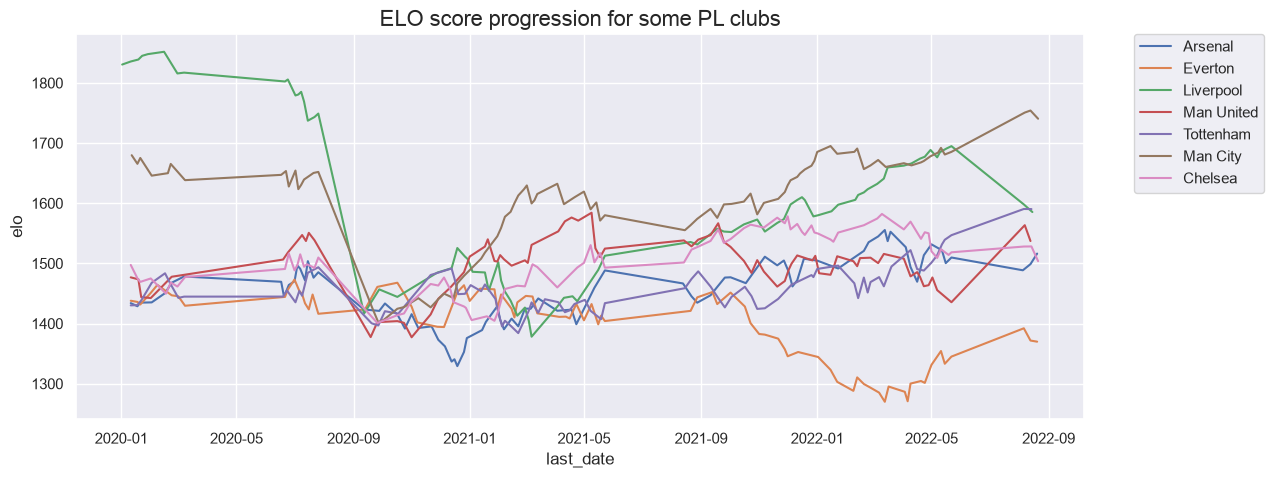

In [27]:
plt.figure(figsize = (13,5))
sns.lineplot(x='last_date', y='elo', hue='team', errorbar=None,
    data=league_table_elo_all[(league_table_elo_all['team'].isin(['Arsenal', 'Chelsea', 'Liverpool', 'Man City', 'Man United', 'Tottenham', 'Everton'])) & (league_table_elo_all['last_date'] > '2020-01-01')])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('ELO score progression for some PL clubs', size = 16)

In [28]:
#plt.figure(figsize = (15,8))
#sns.lineplot(x='matched_played', y='elo', hue='team', ci = None,
#    data=league_table_elo_all[(league_table_elo_all['team'].isin(['Arsenal', 'Chelsea', 'Liverpool', 'Man City', 'Man United', 'Tottenham', 'Everton'])) & (league_table_elo_all['matched_played'] > 100)])
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Summary: